In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, stats
import itertools

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
})
plt.rc('text', usetex=False)
plt.rc('mathtext', fontset='stix')
figsize = (7, 5)
fontSize = 13

In [ ]:
# --- TetR soluble / insoluble fractionation (Supplementary Figure S17) -----
QUANT = Path("western_blot/raw/QUANT_Tet_r.csv")

lanes = pd.read_csv(QUANT, nrows=14)
lanes

In [ ]:
# --- densitometry from the raw 16-bit chemiluminescence TIF ----------------

from PIL import Image
Image.MAX_IMAGE_PIXELS = None

TIF   = Path("western_blot/raw/Tet_r_Signal.tif")
X0, DX   = 190.7, 74.56        # lane-1 centre, lane pitch (TIF px)
BAND     = (204, 364)          # band window rows
BG_ROWS  = 60                  # background strip height, immediately above BAND

img = np.array(Image.open(TIF)).astype(float)
print("image", img.shape, "16-bit range %d-%d" % (img.min(), img.max()))

SAMPLES = ['NC', 'PC+LVA', 'PC-LVA', 'BD3 ON', 'BD3 OFF', 'BD4 ON', 'BD4 OFF']

rows = []
for lane in range(14):
    cx = X0 + lane * DX
    x0, x1 = int(round(cx - DX / 2)), int(round(cx + DX / 2))
    band = img[BAND[0]:BAND[1], x0:x1]
    bg   = np.median(img[BAND[0] - BG_ROWS:BAND[0], x0:x1])
    rows.append({'lane': lane + 1,
                 'sample': SAMPLES[lane // 2],
                 'fraction': 'S' if lane % 2 == 0 else 'P',
                 'x0': x0, 'x1': x1, 'y0': BAND[0], 'y1': BAND[1],
                 'background': bg,
                 'integrated_signal': band.sum() - bg * band.size})

dens = pd.DataFrame(rows)
dens['relative_to_max'] = (dens['integrated_signal']
                           / dens['integrated_signal'].max()).round(4)
dens

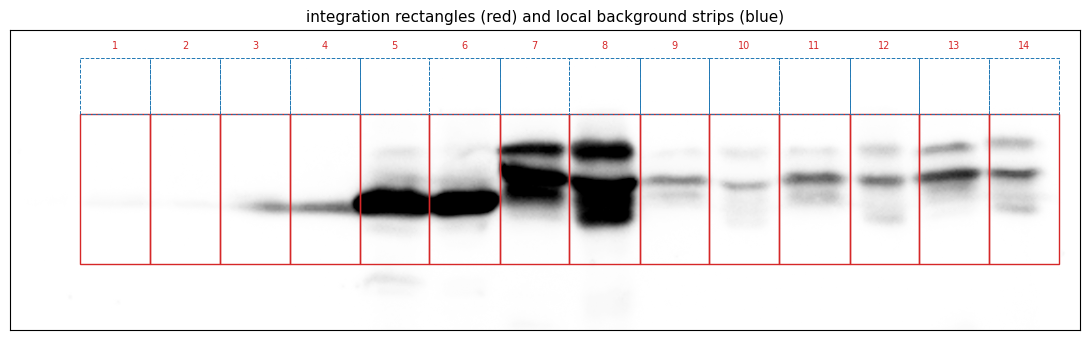

In [4]:
# --- show the integration rectangles on the blot ---------------------------

from matplotlib.patches import Rectangle

lo, hi = np.percentile(img, 5), np.percentile(img, 99.5)
disp = 1.0 - np.clip((img - lo) / (hi - lo), 0, 1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.imshow(disp, cmap='gray', vmin=0, vmax=1)
for _, r in dens.iterrows():
    ax.add_patch(Rectangle((r.x0, r.y0), r.x1 - r.x0, r.y1 - r.y0,
                           fill=False, ec='#D62728', lw=1.0))
    ax.add_patch(Rectangle((r.x0, r.y0 - BG_ROWS), r.x1 - r.x0, BG_ROWS,
                           fill=False, ec='#1F77B4', lw=0.7, ls='--'))
    ax.text((r.x0 + r.x1) / 2, r.y0 - BG_ROWS - 8, "%d" % r.lane,
            ha='center', va='bottom', fontsize=7, color='#D62728')
ax.set_xlim(X0 - 1.5 * DX, X0 + 13.8 * DX)
ax.set_ylim(BAND[1] + 70, BAND[0] - BG_ROWS - 30)
ax.set_title('integration rectangles (red) and local background strips (blue)',
             fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig('western_blot/western_densitometry_rectangles.pdf')
plt.show()

In [5]:
# --- soluble fraction per strain -------------------------------------------
w = pd.read_csv(QUANT, skiprows=15).set_index('sample')
w['soluble_fraction'] = w['S'] / w['total']
w = w.sort_values('soluble_fraction')
w

,S,P,total,percent_soluble,percent_insoluble,soluble_fraction
sample,,,,,,
PC+LVA,7101629,16188564,23290193,30.5,69.5,0.304919
BD3 ON,127615511,166541632,294157143,43.4,56.6,0.433834
PC-LVA,87562524,90758068,178320592,49.1,50.9,0.491040
BD4 ON,23622593,19820732,43443325,54.4,45.6,0.543757
NC,963101,799464,1762565,54.6,45.4,0.546420
BD4 OFF,36564408,25509438,62073846,58.9,41.1,0.589047
BD3 OFF,16321295,10256580,26577875,61.4,38.6,0.614093


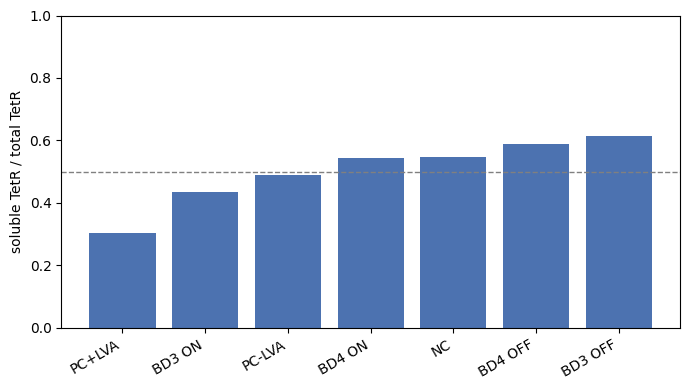

In [6]:
# --- Figure : soluble fraction ---------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(w.index, w['soluble_fraction'], color='#4C72B0')
ax.set_ylabel('soluble TetR / total TetR')
ax.set_ylim(0, 1)
ax.axhline(0.5, ls='--', lw=1, color='grey')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('western_blot/western_tetr_solubility_notebook.pdf')
plt.show()